<a href="https://colab.research.google.com/github/Adr1an12/Detec-o-de-Anomalias/blob/main/Deteccao_de_anomalias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

df = pd.read_csv('acessos_sistema.csv')

print(df.head())

Saving acessos_sistema.csv to acessos_sistema.csv
   hora_acesso  duracao_sessao_min  numero_tentativas_login  \
0            9                  35                        1   
1           10                  40                        1   
2           11                  25                        1   
3           14                  50                        1   
4           15                  45                        1   

   ip_diferente_habitual  quantidade_paginas_acessadas  
0                      0                            12  
1                      0                            15  
2                      0                             9  
3                      0                            18  
4                      0                            16  


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(df)

In [3]:
from sklearn.ensemble import IsolationForest

modelo = IsolationForest(
    contamination=0.05,
    random_state=42
)

df["anomalia"] = modelo.fit_predict(X)

In [4]:
anomalias = df[df["anomalia"] == -1]

print(anomalias)

    hora_acesso  duracao_sessao_min  numero_tentativas_login  \
42            1                 120                        1   
54           23                 300                        1   
71           22                 300                        1   
75            3                 240                        1   

    ip_diferente_habitual  quantidade_paginas_acessadas  anomalia  
42                      1                            60        -1  
54                      1                           110        -1  
71                      1                           120        -1  
75                      1                           110        -1  


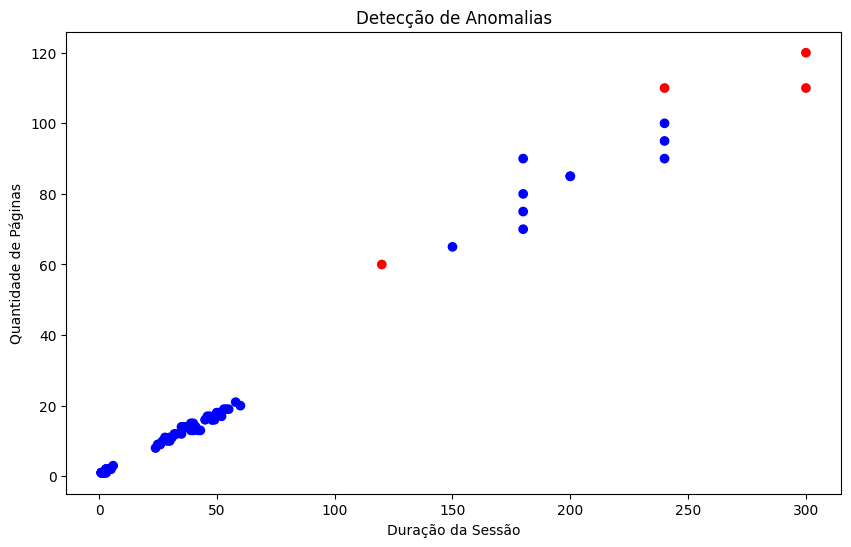

In [5]:
import matplotlib.pyplot as plt

cores = df["anomalia"].map({1: "blue", -1: "red"})

plt.figure(figsize=(10,6))
plt.scatter(
    df["duracao_sessao_min"],
    df["quantidade_paginas_acessadas"],
    c=cores
)

plt.xlabel("Duração da Sessão")
plt.ylabel("Quantidade de Páginas")
plt.title("Detecção de Anomalias")
plt.show()